<a href="https://colab.research.google.com/github/kimjiwoo2/Pill-agent/blob/develop/notebooks/jiwoo/W1_jw_gcs_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **GCS 테스트**

## Set-up

In [ ]:
from google.colab import auth

# 계정 인증
auth.authenticate_user()

# 프로젝트 설정
!gcloud config set project pilliot-495707

Are you sure you wish to set property [core/project] to pilliot-495707?

Do you want to continue (Y/n)?  y

Updated property [core/project].


In [ ]:
# GCS 경로 확인
!gcloud storage ls gs://pilliot-raw-data-2026/

gs://pilliot-raw-data-2026/test.txt
gs://pilliot-raw-data-2026/test_wsl.txt
gs://pilliot-raw-data-2026/00_original_zip/
gs://pilliot-raw-data-2026/gcloud/


In [ ]:
# 세부 경로 확인
!gcloud storage ls gs://pilliot-raw-data-2026/00_original_zip/aihub_576_oral_pill/

gs://pilliot-raw-data-2026/00_original_zip/aihub_576_oral_pill/combination/
gs://pilliot-raw-data-2026/00_original_zip/aihub_576_oral_pill/single/


- **AIHub 경구약제 데이터 원본 경로**:  백업용이므로 삭제하거나 수정하지 말 것

  gs://pilliot-raw-data-2026/00_original_zip/aihub/

- **GCS 버킷:**

  gs://pilliot-raw-data-2026/


- **AIHub 경구약제 데이터 경로:**

  gs://pilliot-raw-data-2026/00_original_zip/aihub_576_oral_pill/

```
00_original_zip/
└── aihub_576_oral_pill/
    ├── combination/
    │   ├── train/
    │   │   ├── images/    → 조합 경구약제 Training 이미지 zip
    │   │   └── labels/    → 조합 경구약제 Training 라벨 zip
    │   └── validation/
    │       ├── images/    → 조합 경구약제 Validation 이미지 zip
    │       └── labels/    → 조합 경구약제 Validation 라벨 zip
    └── single/
        ├── train/
        │   ├── images/    → 단일 경구약제 Training 이미지 zip
        │   └── labels/    → 단일 경구약제 Training 라벨 zip
        └── validation/
            ├── images/    → 단일 경구약제 Validation 이미지 zip
            └── labels/    → 단일 경구약제 Validation 라벨 zip
```

## Sample

### 1. 조합 데이터 1세트 다운로드

: 모델 테스트나 JSON 구조 확인을 위해 조합 데이터 1세트만 사용할 경우.

In [ ]:
!mkdir -p /content/pill_sample

!gcloud storage cp \
gs://pilliot-raw-data-2026/00_original_zip/aihub_576_oral_pill/combination/train/images/TS_1_조합.zip \
/content/pill_sample/

!gcloud storage cp \
gs://pilliot-raw-data-2026/00_original_zip/aihub_576_oral_pill/combination/train/labels/TL_1_조합.zip \
/content/pill_sample/

In [ ]:
# crcmod 설치
!pip install crcmod

# 이미지 다시 다운로드
!gsutil cp \
gs://pilliot-raw-data-2026/00_original_zip/aihub_576_oral_pill/combination/train/images/TS_1_조합.zip \
/content/pill_sample/

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.7/89.7 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for crcmod: filename=crcmod-1.7-cp312-cp312-linux_x86_64.whl size=31836 sha256=fe98f25b12f56bd260560ddedec258db0c47a712dc1746c8949649db3e0a3628
  Stored in directory: /root/.cache/pip/wheels/76/08/0b/caa8b1380122cbfe6a03eaccbec0f63c67e619af4e30ca5e2a
Successfully built crcmod
Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying gs://pilliot-raw-data-2026/00_original_zip/aihub_576_oral_pill/combination/train/images/TS_1_조합.zip...
- [1 files][  3.5 GiB/  3.5 GiB]   63.7 MiB/s                                   
Operation completed over 1 objects/3.5 GiB.                                      


In [ ]:
!unzip -q /content/pill_sample/TS_1_조합.zip -d /content/pill_sample/unzipped_images
!unzip -q /content/pill_sample/TL_1_조합.zip -d /content/pill_sample/unzipped_labels

In [ ]:
!find /content/pill_sample -type f | head

/content/pill_sample/unzipped_images/K-000573-001866-023223-044834/K-000573-001866-023223-044834_0_2_0_2_75_000_200.png
/content/pill_sample/unzipped_images/K-000573-001866-023223-044834/K-000573-001866-023223-044834_index.png
/content/pill_sample/unzipped_images/K-000573-001866-023223-044834/K-000573-001866-023223-044834_0_2_0_2_90_000_200.png
/content/pill_sample/unzipped_images/K-000573-001866-023223-044834/K-000573-001866-023223-044834_0_2_0_2_70_000_200.png
/content/pill_sample/unzipped_images/K-000250-002483-006192-013395/K-000250-002483-006192-013395_0_2_0_2_75_000_200.png
/content/pill_sample/unzipped_images/K-000250-002483-006192-013395/K-000250-002483-006192-013395_index.png
/content/pill_sample/unzipped_images/K-000250-002483-006192-013395/K-000250-002483-006192-013395_0_2_0_2_90_000_200.png
/content/pill_sample/unzipped_images/K-000250-002483-006192-013395/K-000250-002483-006192-013395_0_2_0_2_70_000_200.png
/content/pill_sample/unzipped_images/K-000573-001866-006192-044834

총 이미지 수: 2012장


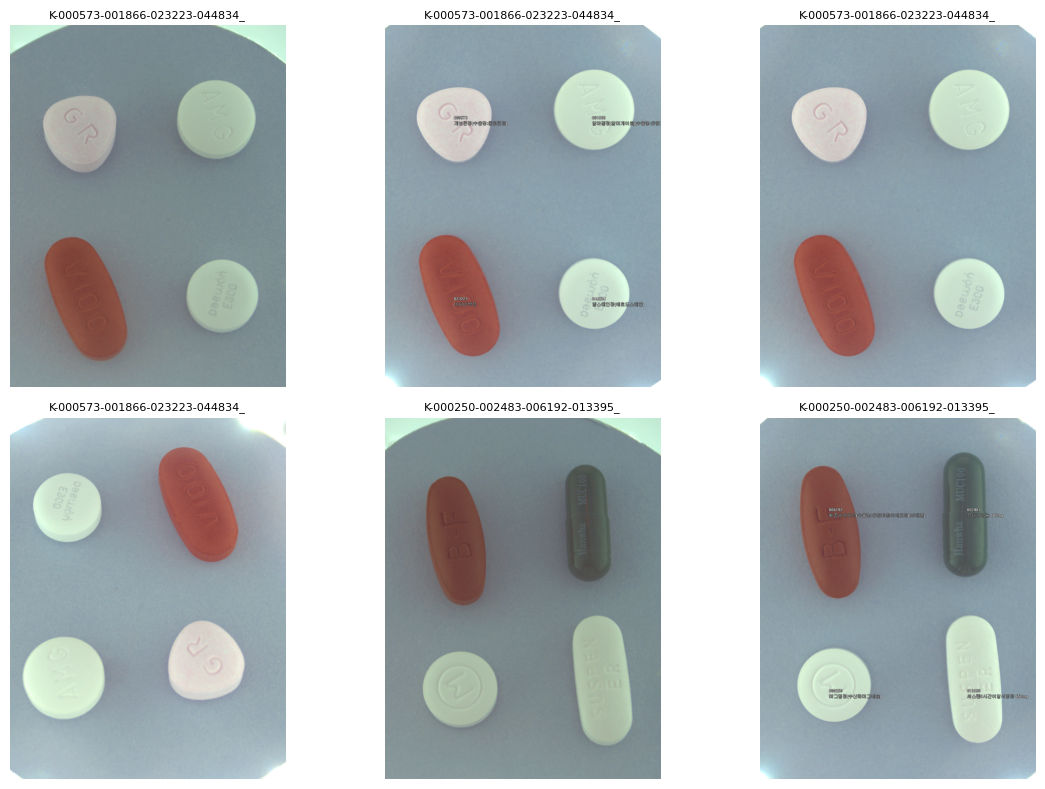

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import glob

# 이미지 파일 목록 가져오기
images = glob.glob('/content/pill_sample/unzipped_images/**/*.png', recursive=True)
print(f"총 이미지 수: {len(images)}장")

# 처음 6장 보기
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for i, ax in enumerate(axes.flat):
    img = mpimg.imread(images[i])
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(images[i].split('/')[-1][:30], fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
import json, glob

labels = glob.glob('/content/pill_sample/unzipped_labels/**/*.json', recursive=True)
print(f"총 라벨 수: {len(labels)}개")

# 하나 열어보기
with open(labels[0]) as f:
    data = json.load(f)
print(json.dumps(data, indent=2, ensure_ascii=False))

총 라벨 수: 6011개
{
  "images": [
    {
      "file_name": "K-000250-002483-019552-022362_0_2_0_2_75_000_200.png",
      "width": 976,
      "height": 1280,
      "imgfile": "K-000250-002483-019552-022362_0_2_0_2_75_000_200.png",
      "drug_N": "K-002483",
      "drug_S": "정상알약",
      "back_color": "연회색 배경",
      "drug_dir": "앞면",
      "light_color": "주백색",
      "camera_la": 75,
      "camera_lo": 0,
      "size": 200,
      "dl_idx": "2482",
      "dl_mapping_code": "K-002483",
      "dl_name": "뮤테란캡슐 100mg",
      "dl_name_en": "Muteran Cap. 100mg",
      "img_key": "http://connectdi.com/design/img/drug/1M_4NHfUrnp.jpg",
      "dl_material": "아세틸시스테인",
      "dl_material_en": "Acetylcysteine",
      "dl_custom_shape": "경질캡슐제",
      "dl_company": "한화제약(주)",
      "dl_company_en": "Hanwha Pharma",
      "di_company_mf": "",
      "di_company_mf_en": "",
      "item_seq": 198801531,
      "di_item_permit_date": "19880629",
      "di_class_no": "[02220]진해거담제",
      "di_etc_otc_code": 

### 2. 단일 데이터 1세트 다운로드

: 단일 경구약제 데이터 일부를 확인하는 경우.

In [ ]:
!mkdir -p /content/pill_single_sample

!gcloud storage cp \
gs://pilliot-raw-data-2026/00_original_zip/aihub_576_oral_pill/single/train/images/TS_10_단일.zip \
/content/pill_single_sample/

!gcloud storage cp \
gs://pilliot-raw-data-2026/00_original_zip/aihub_576_oral_pill/single/train/labels/TL_10_단일.zip \
/content/pill_single_sample/

In [ ]:
!unzip -q /content/pill_single_sample/TS_10_단일.zip -d /content/pill_single_sample/unzipped_images
!unzip -q /content/pill_single_sample/TL_10_단일.zip -d /content/pill_single_sample/unzipped_labels

-> 디스크 용량 이슈로 인해 다운로드 불가능